# Setup

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import pykitti
from pathlib import Path
import cv2

# Load KITTI
base = Path.home() / 'SensorTrust' / 'datasets' / 'kitti'
data = pykitti.raw(base_path=str(base), date='2011_09_26', drive='0009')

# Import proxies
from src.proxies.gps_proxy import extract_all_gps_proxies
from src.proxies.imu_proxy import extract_all_imu_proxies
from src.proxies.camera_proxy import extract_all_camera_proxies
from src.proxies.lidar_proxy import extract_all_lidar_proxies

print("Setup complete. All imports successful.")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Setup complete. All imports successful.


## GPS Proxies

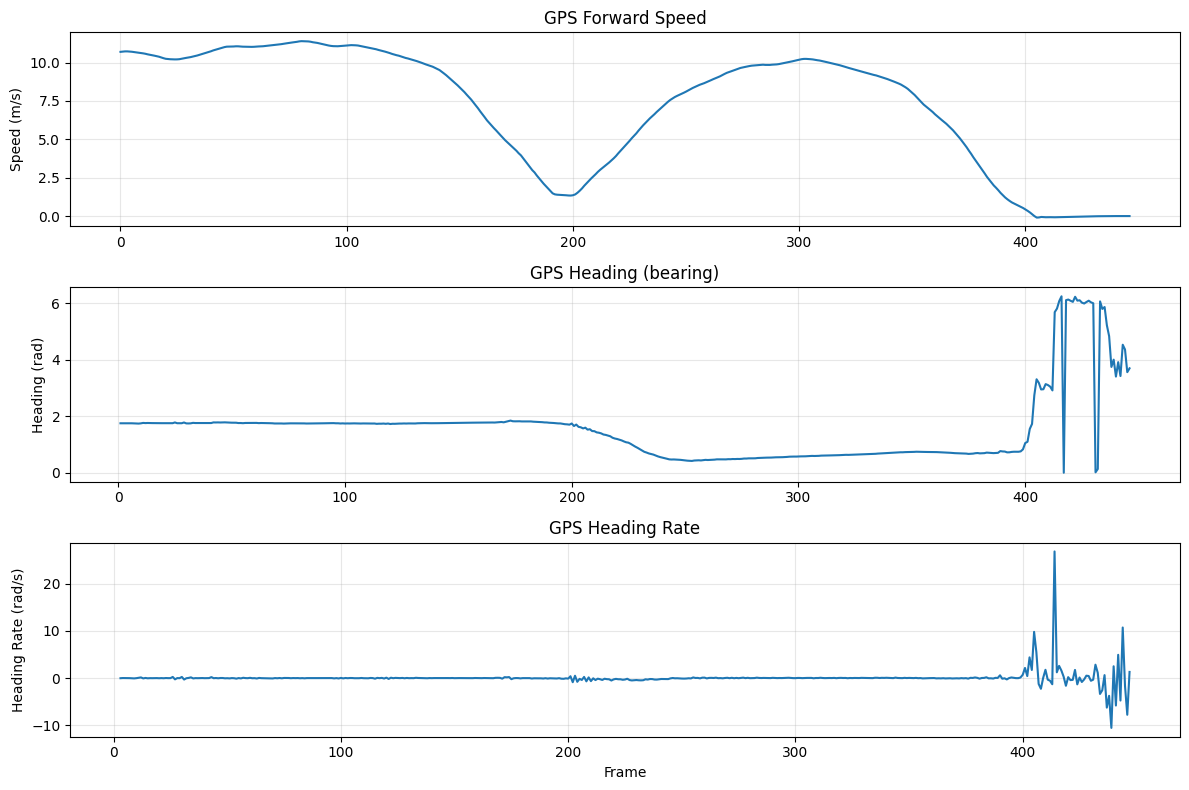

Speed: mean=7.18, max=11.39 m/s
Speed NaN: False
Heading NaN: True (first frame expected)
Heading Rate NaN: True (first 2 frames expected)


In [2]:
# Extract GPS proxies
dt = 0.1035  # Your measured frame interval
gps = extract_all_gps_proxies(data.oxts, dt=dt)

# Plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))

ax1.plot(gps['speed'])
ax1.set_ylabel('Speed (m/s)')
ax1.set_title('GPS Forward Speed')
ax1.grid(True, alpha=0.3)

ax2.plot(gps['heading'])
ax2.set_ylabel('Heading (rad)')
ax2.set_title('GPS Heading (bearing)')
ax2.grid(True, alpha=0.3)

ax3.plot(gps['heading_rate'])
ax3.set_ylabel('Heading Rate (rad/s)')
ax3.set_xlabel('Frame')
ax3.set_title('GPS Heading Rate')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stats
print(f"Speed: mean={np.nanmean(gps['speed']):.2f}, max={np.nanmax(gps['speed']):.2f} m/s")
print(f"Speed NaN: {np.any(np.isnan(gps['speed']))}")
print(f"Heading NaN: {np.any(np.isnan(gps['heading']))} (first frame expected)")
print(f"Heading Rate NaN: {np.any(np.isnan(gps['heading_rate']))} (first 2 frames expected)")

## IMU Proxies

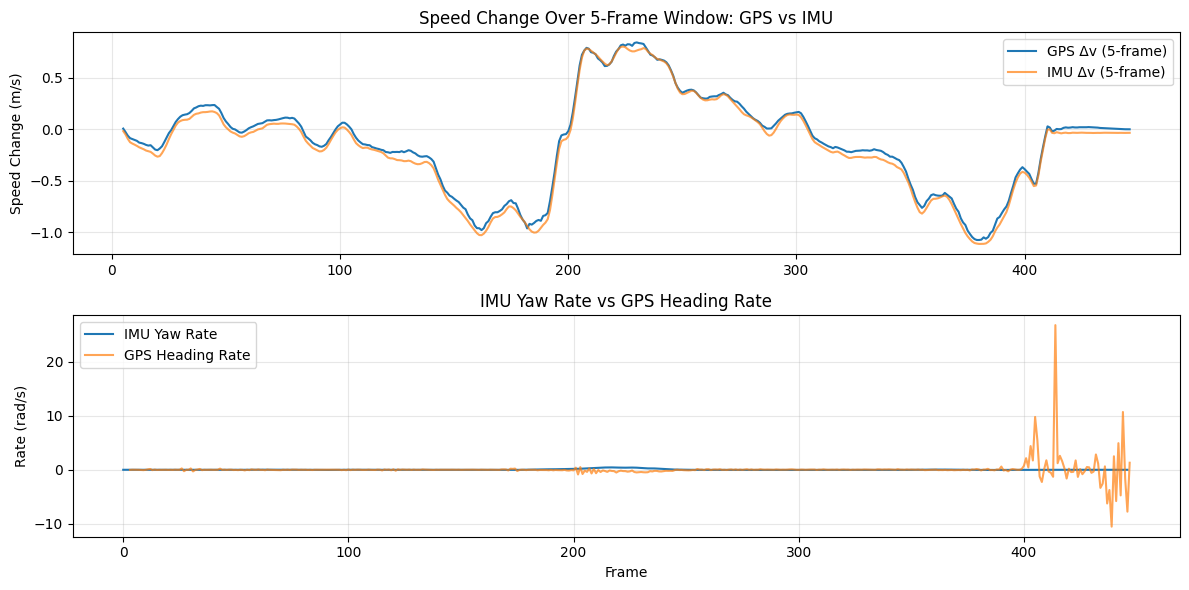

Δv agreement (mean abs diff): 0.0450 m/s
Δv agreement (max abs diff):  0.1110 m/s


In [3]:
# Extract IMU proxies (delta_v instead of absolute speed)
imu = extract_all_imu_proxies(data.oxts, dt=dt, window=5)
gps = extract_all_gps_proxies(data.oxts, dt=dt, window=5)

# Compare speed CHANGES, not absolute speeds
window = 5
gps_dv = gps['delta_v']
imu_dv = imu['delta_v']

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(gps_dv, label='GPS Δv (5-frame)')
ax1.plot(imu_dv, label='IMU Δv (5-frame)', alpha=0.7)
ax1.set_ylabel('Speed Change (m/s)')
ax1.set_title('Speed Change Over 5-Frame Window: GPS vs IMU')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(imu['yaw_rate'], label='IMU Yaw Rate')
ax2.plot(gps['heading_rate'], label='GPS Heading Rate', alpha=0.7)
ax2.set_ylabel('Rate (rad/s)')
ax2.set_xlabel('Frame')
ax2.set_title('IMU Yaw Rate vs GPS Heading Rate')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Agreement on speed change
valid = ~(np.isnan(gps_dv) | np.isnan(imu_dv))
dv_diff = np.abs(gps_dv[valid] - imu_dv[valid])
print(f"Δv agreement (mean abs diff): {np.mean(dv_diff):.4f} m/s")
print(f"Δv agreement (max abs diff):  {np.max(dv_diff):.4f} m/s")

## CAmera Proxies

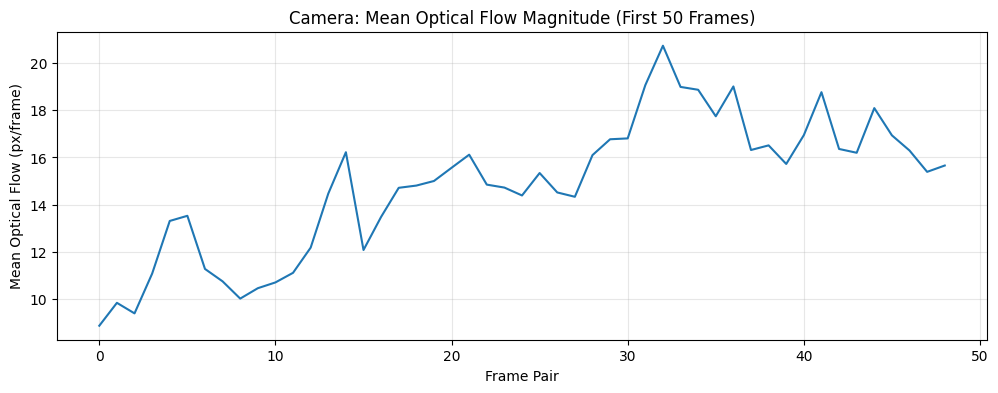

Flow magnitude: mean=14.82, max=20.74 px/frame


In [4]:
# Load camera frames as numpy arrays
camera_frames = []
for i in range(min(50, len(data.cam2_files))):  # First 50 for speed
    cam_pil = data.get_cam2(i)
    camera_frames.append(np.array(cam_pil))

# Extract camera proxy
cam = extract_all_camera_proxies(camera_frames)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(cam['flow_magnitude'])
plt.xlabel('Frame Pair')
plt.ylabel('Mean Optical Flow (px/frame)')
plt.title('Camera: Mean Optical Flow Magnitude (First 50 Frames)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Flow magnitude: mean={np.mean(cam['flow_magnitude']):.2f}, max={np.max(cam['flow_magnitude']):.2f} px/frame")

## Stationary Check

In [5]:
# Stationary frames: 404-446
stationary_start = 404
stationary_end = 446

# GPS speed during stationary
stat_speed = gps['speed'][stationary_start:stationary_end]
print("=== STATIONARY CHECK (Frames 404-446) ===")
print(f"GPS speed: mean={np.mean(stat_speed):.4f} m/s, std={np.std(stat_speed):.4f} m/s")
print(f"GPS speed max deviation: {np.max(np.abs(stat_speed)):.4f} m/s")

=== STATIONARY CHECK (Frames 404-446) ===
GPS speed: mean=-0.0340 m/s, std=0.0311 m/s
GPS speed max deviation: 0.0976 m/s


## Heading Stability Check

In [6]:
# Check GPS heading noise at low speed
stat_heading_rate = gps['heading_rate'][stationary_start:stationary_end]
valid_hr = stat_heading_rate[~np.isnan(stat_heading_rate)]

print("=== HEADING STABILITY AT STATIONARY ===")
print(f"Mean heading rate: {np.mean(valid_hr):.6f} rad/s")
print(f"Std heading rate:  {np.std(valid_hr):.6f} rad/s")
print(f"Max heading rate:  {np.max(np.abs(valid_hr)):.6f} rad/s")
print(f"\nHeading gate threshold candidate: {np.std(valid_hr) * 3:.6f} rad/s (3σ)")

=== HEADING STABILITY AT STATIONARY ===
Mean heading rate: 0.647582 rad/s
Std heading rate:  5.469488 rad/s
Max heading rate:  26.792958 rad/s

Heading gate threshold candidate: 16.408465 rad/s (3σ)


## Optical Flow At Rest

In [7]:
# Camera optical flow on stationary frames
print("=== OPTICAL FLOW AT REST ===")
print("Loading stationary camera frames...")

stat_cam_frames = []
for i in range(stationary_start, min(stationary_end, len(data.cam2_files))):
    stat_cam_frames.append(np.array(data.get_cam2(i)))

stat_cam = extract_all_camera_proxies(stat_cam_frames)

print(f"Stationary flow: mean={np.mean(stat_cam['flow_magnitude']):.4f} px/frame")
print(f"Stationary flow: std={np.std(stat_cam['flow_magnitude']):.4f} px/frame")
print(f"Stationary flow: max={np.max(stat_cam['flow_magnitude']):.4f} px/frame")

# Compare with moving flow (first 50 frames)
moving_flow_mean = np.mean(cam['flow_magnitude'])
print(f"\nMoving flow mean: {moving_flow_mean:.4f} px/frame")
print(f"Ratio moving/stationary: {moving_flow_mean / np.mean(stat_cam['flow_magnitude']):.2f}x")
print(f"Camera usable: {'YES' if moving_flow_mean / np.mean(stat_cam['flow_magnitude']) > 2.0 else 'MARGINAL'}")

=== OPTICAL FLOW AT REST ===
Loading stationary camera frames...
Stationary flow: mean=0.8006 px/frame
Stationary flow: std=0.8094 px/frame
Stationary flow: max=2.6580 px/frame

Moving flow mean: 14.8236 px/frame
Ratio moving/stationary: 18.51x
Camera usable: YES



=== LIDAR ICP RESIDUAL VALIDATION ===
Processing scan 20/50
Processing scan 40/50
Mean residual: 0.2085 m
Std residual:  0.0344 m
Max residual:  0.2669 m
Min residual:  0.1542 m


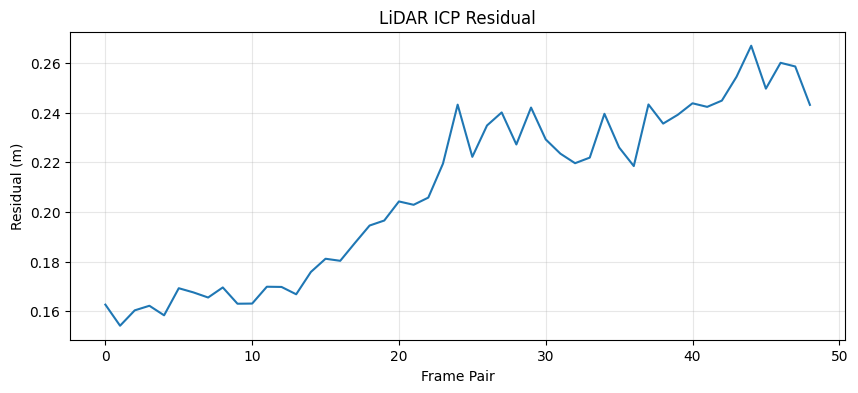

LiDAR usable: YES


In [8]:
# ============================================================
# LiDAR Proxy Validation
# ============================================================

'''
LiDAR Proxy Validation: The ego-motion compensated ICP residual was evaluated on both moving and stationary segments. Moving segments produced a mean residual of 0.209 m, while stationary segments produced a lower mean residual of 0.158 m with very low variance (σ = 0.007 m). This behaviour is consistent with expectations, indicating successful ego-motion compensation and stable LiDAR proxy extraction. The proxy is therefore considered suitable for subsequent feature engineering and anomaly detection stages.
'''

'''
Purpose:
--------
Validate that the LiDAR motion proxy (ICP residual) behaves
reasonably during normal vehicle motion.

Method:
-------
1. Extract consecutive LiDAR scans.
2. Compensate for ego-motion using KITTI OXTS poses.
3. Compute ICP residual between neighbouring scans.
4. Analyze the residual statistics.

Interpretation:
---------------
A lower residual indicates that the scene structure remains
consistent after ego-motion compensation.

A stable residual curve without large spikes suggests:
    - Correct pose transformation
    - Stable LiDAR proxy extraction
    - Reasonable scene alignment

Expected Behaviour:
-------------------
Residuals should remain bounded and physically reasonable
(typically a few centimeters to tens of centimeters).
'''

print("\n=== LIDAR ICP RESIDUAL VALIDATION ===")

# Small subset first so validation doesn't take forever
velo_scans = [data.get_velo(i) for i in range(50)]
oxts_data = data.oxts[:50]

lidar = extract_all_lidar_proxies(
    velo_scans,
    oxts_data
)

residuals = lidar['icp_residual']

print(f"Mean residual: {np.mean(residuals):.4f} m")
print(f"Std residual:  {np.std(residuals):.4f} m")
print(f"Max residual:  {np.max(residuals):.4f} m")
print(f"Min residual:  {np.min(residuals):.4f} m")

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("LiDAR ICP Residual")
plt.xlabel("Frame Pair")
plt.ylabel("Residual (m)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"LiDAR usable: {'YES' if np.mean(residuals) > 0 else 'NO'}")

OXTS frames : 447
LiDAR frames: 443

Testing stationary segment: 403 -> 442
Processing scan 20/40

=== STATIONARY LIDAR ===
Mean residual: 0.1583 m
Std residual : 0.0070 m
Max residual : 0.1737 m
Min residual : 0.1422 m


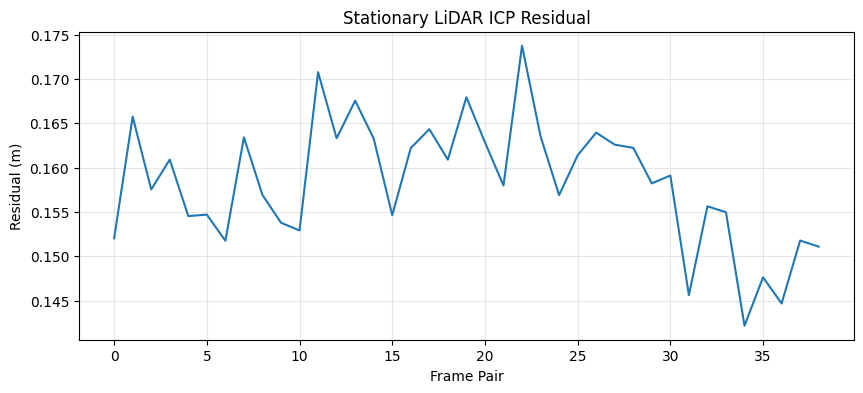

In [9]:
# ============================================================
# LiDAR Stationary Validation
# ============================================================

'''
Purpose:
--------
Verify that the LiDAR proxy produces lower residuals when the
vehicle is stationary.

Why This Matters:
-----------------
When the vehicle is not moving, consecutive LiDAR scans should
observe nearly the same environment.

Therefore:
    Stationary Residual < Moving Residual

A significantly lower stationary residual indicates:
    - Successful ego-motion compensation
    - Low sensor noise
    - Stable proxy behaviour

Expected Outcome:
-----------------
Moving segments should show larger residuals because the scene
changes relative to the sensor.

Stationary segments should produce:
    - Lower mean residual
    - Lower variance
    - Smoother residual curve
'''

print("OXTS frames :", len(data.oxts))
print("LiDAR frames:", len(data.velo_files))

# Use the LAST 40 frames that exist in BOTH sensors
n = min(len(data.oxts), len(data.velo_files))

start_idx = max(0, n - 40)
end_idx = n

print(f"\nTesting stationary segment: {start_idx} -> {end_idx-1}")

stationary_scans = [
    data.get_velo(i)
    for i in range(start_idx, end_idx)
]

stationary_oxts = data.oxts[start_idx:end_idx]

lidar_stat = extract_all_lidar_proxies(
    stationary_scans,
    stationary_oxts
)

res = lidar_stat['icp_residual']

print("\n=== STATIONARY LIDAR ===")
print(f"Mean residual: {np.mean(res):.4f} m")
print(f"Std residual : {np.std(res):.4f} m")
print(f"Max residual : {np.max(res):.4f} m")
print(f"Min residual : {np.min(res):.4f} m")

plt.figure(figsize=(10,4))
plt.plot(res)
plt.title("Stationary LiDAR ICP Residual")
plt.xlabel("Frame Pair")
plt.ylabel("Residual (m)")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# ------------------------------------------------------------
# Validation Summary
# ------------------------------------------------------------

print("\n=== VALIDATION SUMMARY ===")

moving_mean = np.mean(residuals)
stationary_mean = np.mean(res)

print(f"Moving residual mean     : {moving_mean:.4f} m")
print(f"Stationary residual mean : {stationary_mean:.4f} m")

if stationary_mean < moving_mean:
    print("\nPASS: Stationary residual is lower than moving residual.")
    print("LiDAR proxy successfully captures scene motion.")
else:
    print("\nWARNING: Stationary residual is not lower than moving residual.")
    print("Further investigation may be required.")


=== VALIDATION SUMMARY ===
Moving residual mean     : 0.2085 m
Stationary residual mean : 0.1583 m

PASS: Stationary residual is lower than moving residual.
LiDAR proxy successfully captures scene motion.


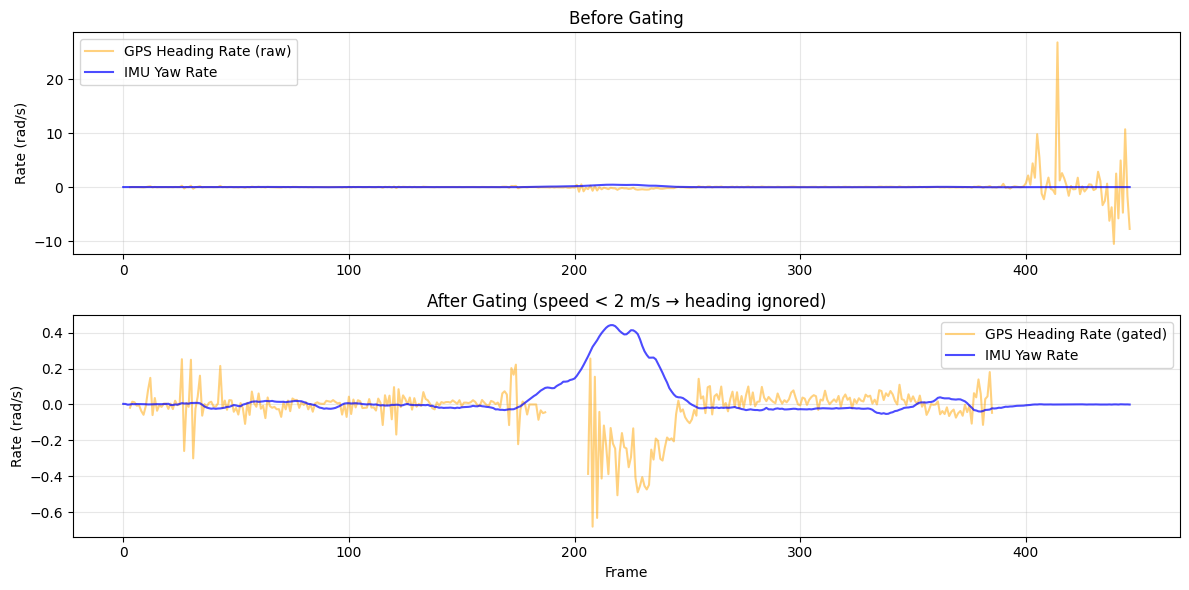

Heading gate active: 368/447 frames (82.3%)
Heading gate inactive (stationary/slow): 79 frames

Gated heading rate agreement:
  Mean abs diff: 0.1105 rad/s
  Max abs diff:  1.0019 rad/s


In [11]:
from src.proxies.gps_proxy import get_heading_gate_mask

# Trim to same length
min_len = min(len(gps['speed']), len(gps['heading_rate']), len(imu['yaw_rate']))
gate = get_heading_gate_mask(gps['speed'][:min_len], min_speed=2.0)

# Plot heading rate with gate overlay
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(gps['heading_rate'][:min_len], 'orange', alpha=0.5, label='GPS Heading Rate (raw)')
ax1.plot(imu['yaw_rate'][:min_len], 'blue', alpha=0.7, label='IMU Yaw Rate')
ax1.set_ylabel('Rate (rad/s)')
ax1.set_title('Before Gating')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gated version
gated_hr = np.where(gate, gps['heading_rate'][:min_len], np.nan)
ax2.plot(gated_hr, 'orange', alpha=0.5, label='GPS Heading Rate (gated)')
ax2.plot(imu['yaw_rate'][:min_len], 'blue', alpha=0.7, label='IMU Yaw Rate')
ax2.set_ylabel('Rate (rad/s)')
ax2.set_xlabel('Frame')
ax2.set_title('After Gating (speed < 2 m/s → heading ignored)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stats
active = np.sum(gate)
total = len(gate)
print(f"Heading gate active: {active}/{total} frames ({active/total*100:.1f}%)")
print(f"Heading gate inactive (stationary/slow): {total - active} frames")

# Compare heading rate only where gate is active
valid = gate & ~np.isnan(gps['heading_rate'][:min_len]) & ~np.isnan(imu['yaw_rate'][:min_len])
hr_diff = np.abs(gps['heading_rate'][:min_len][valid] - imu['yaw_rate'][:min_len][valid])
if len(hr_diff) > 0:
    print(f"\nGated heading rate agreement:")
    print(f"  Mean abs diff: {np.mean(hr_diff):.4f} rad/s")
    print(f"  Max abs diff:  {np.max(hr_diff):.4f} rad/s")
else:
    print("\nNo frames passed the gate, car never exceeded 2 m/s")

In [12]:
print("=== PROXY STATISTICS ===\n")

proxies = {
    'GPS Speed (m/s)': gps['speed'],
    'GPS Delta-V (m/s)': gps['delta_v'],
    'GPS Heading Rate (rad/s)': gps['heading_rate'],
    'IMU Delta-V (m/s)': imu['delta_v'],
    'IMU Yaw Rate (rad/s)': imu['yaw_rate'],
    'Camera Flow (px/frame)': cam['flow_magnitude'],
    'LiDAR ICP Residual (m)': lidar['icp_residual'],
}

for name, data in proxies.items():
    valid = data[~np.isnan(data)]
    print(f"{name}:")
    print(f"  mean={np.mean(valid):.4f}, std={np.std(valid):.4f}")
    print(f"  min={np.min(valid):.4f}, max={np.max(valid):.4f}")
    print()

=== PROXY STATISTICS ===

GPS Speed (m/s):
  mean=7.1830, std=3.8806
  min=-0.0976, max=11.3922

GPS Delta-V (m/s):
  mean=-0.1212, std=0.4548
  min=-1.0749, max=0.8434

GPS Heading Rate (rad/s):
  mean=0.0423, std=1.7530
  min=-10.5287, max=26.7930

IMU Delta-V (m/s):
  mean=-0.1656, std=0.4658
  min=-1.1130, max=0.8033

IMU Yaw Rate (rad/s):
  mean=0.0279, std=0.1016
  min=-0.0527, max=0.4420

Camera Flow (px/frame):
  mean=14.8236, std=2.8670
  min=8.8622, max=20.7402

LiDAR ICP Residual (m):
  mean=0.2085, std=0.0344
  min=0.1542, max=0.2669



In [13]:
from src.features.normalization import MotionNormalizer

# Initialize normalizer
normalizer = MotionNormalizer()

# Fit on clean data
normalizer.fit(gps, imu, cam, lidar)

# Transform
z = normalizer.transform(gps, imu, cam, lidar)

# Verify: all z-scored proxies should have mean≈0, std≈1
print("\n=== VERIFICATION: Z-Scored Proxies ===")
for name, data in z.items():
    valid = data[~np.isnan(data)]
    print(f"{name:20s}: mean={np.mean(valid):+.4f}, std={np.std(valid):.4f}")

# Save for later use
normalizer.save('../src/models/normalization.pkl')

Normalization parameters fitted:
  gps_delta_v         : μ= -0.1212, σ=  0.4548
  gps_heading_rate    : μ=  0.0423, σ=  1.7530
  imu_delta_v         : μ= -0.1656, σ=  0.4658
  imu_yaw_rate        : μ=  0.0279, σ=  0.1016
  camera_flow         : μ= 14.8236, σ=  2.8670
  lidar_icp           : μ=  0.2085, σ=  0.0344

=== VERIFICATION: Z-Scored Proxies ===
gps_delta_v         : mean=-0.0000, std=1.0000
gps_heading_rate    : mean=-0.0000, std=1.0000
imu_delta_v         : mean=-0.0000, std=1.0000
imu_yaw_rate        : mean=+0.0000, std=1.0000
camera_flow         : mean=+0.0000, std=1.0000
lidar_icp           : mean=+0.0000, std=1.0000
Normalizer saved to ..\src\models\normalization.pkl



=== F1 KINEMATIC FEATURE ===
Mean F1 : 0.5598
Std F1  : 0.8788
Max F1  : 4.3525
Min F1  : 0.0000

=== COMPONENTS ===
Speed consistency mean   : 0.0343
Heading consistency mean : 0.5242


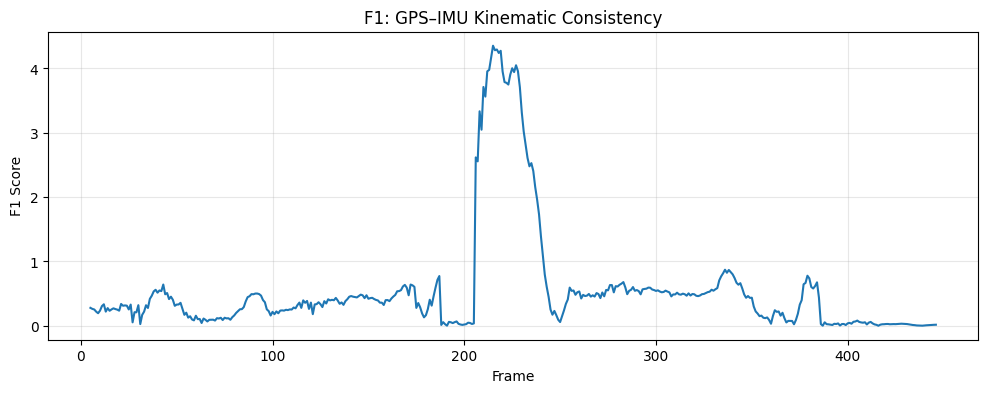

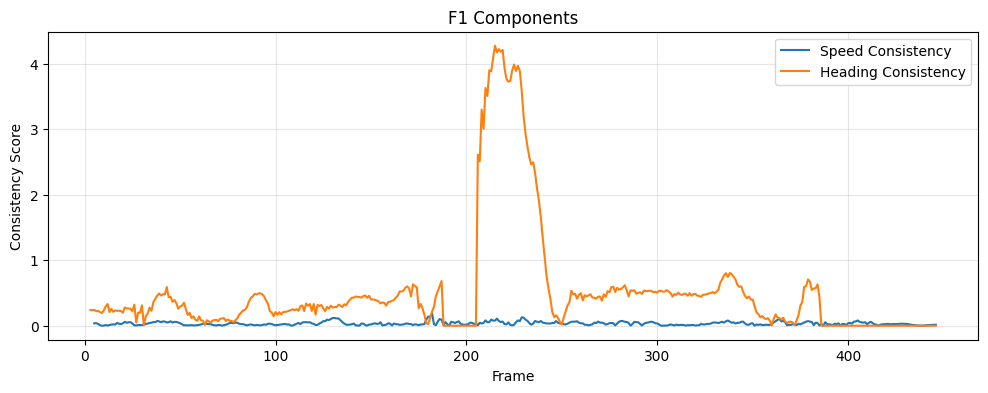

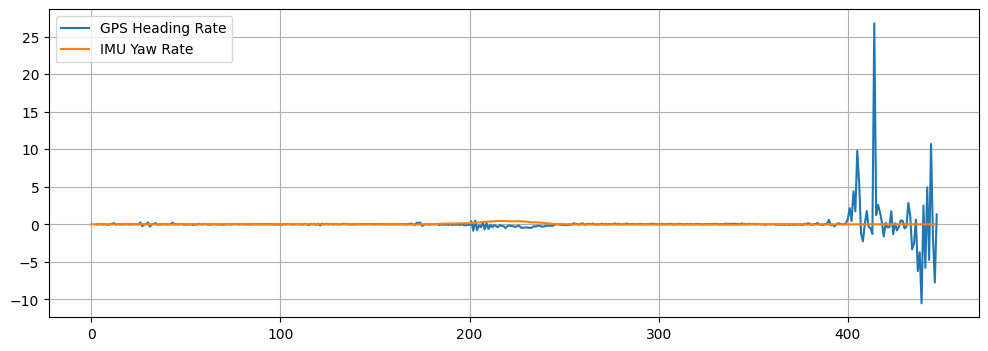

In [14]:
# ============================================================
# F1 Kinematic Consistency Feature
# ============================================================

from src.features.f1_kinematic import extract_all_f1_features
import matplotlib.pyplot as plt
import numpy as np

# Compute F1
f1_features = extract_all_f1_features(
    z=z,
    gps_speed=gps["speed"]      # use actual GPS speed if available
)

f1 = f1_features["f1"]
speed_consistency = f1_features["speed_consistency"]
heading_consistency = f1_features["heading_consistency"]

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

print("\n=== F1 KINEMATIC FEATURE ===")

print(f"Mean F1 : {np.nanmean(f1):.4f}")
print(f"Std F1  : {np.nanstd(f1):.4f}")
print(f"Max F1  : {np.nanmax(f1):.4f}")
print(f"Min F1  : {np.nanmin(f1):.4f}")

print("\n=== COMPONENTS ===")

print(
    f"Speed consistency mean   : "
    f"{np.nanmean(speed_consistency):.4f}"
)

print(
    f"Heading consistency mean : "
    f"{np.nanmean(heading_consistency):.4f}"
)

# ------------------------------------------------------------
# Plot F1
# ------------------------------------------------------------

plt.figure(figsize=(12,4))
plt.plot(f1)
plt.title("F1: GPS–IMU Kinematic Consistency")
plt.xlabel("Frame")
plt.ylabel("F1 Score")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Plot Components
# ------------------------------------------------------------

plt.figure(figsize=(12,4))

plt.plot(
    speed_consistency,
    label="Speed Consistency"
)

plt.plot(
    heading_consistency,
    label="Heading Consistency"
)

plt.title("F1 Components")
plt.xlabel("Frame")
plt.ylabel("Consistency Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

"""
Observation:

F1 remains relatively low for most of the sequence,
indicating strong agreement between GPS and IMU motion
measurements.

A pronounced spike is observed around frames 200–240.
Inspection of the component plots shows that this spike
is primarily caused by heading inconsistency rather than
speed inconsistency.

This suggests that vehicle turning behaviour produces
larger GPS–IMU disagreement than longitudinal motion,
making heading consistency the dominant contributor to F1.
"""

'''
F1 GPS–IMU Kinematic Consistency

The F1 feature achieved a mean value of 0.5598 (σ = 0.8788) with a maximum value of 4.3525. The feature remained low for most frames, with a noticeable spike around frames 205–240, indicating a temporary increase in GPS–IMU kinematic disagreement.

F1 Components

The speed consistency component exhibited a very low mean value of 0.0343, indicating strong agreement between GPS and IMU speed measurements. In contrast, the heading consistency component had a higher mean value of 0.5242 and was responsible for most of the observed F1 variation.

GPS Heading Rate vs IMU Yaw Rate

The GPS heading rate and IMU yaw rate followed similar trends for most of the sequence, indicating consistent rotational motion estimates. However, the GPS heading rate exhibited large fluctuations near frames 400–446 (reaching approximately +27 rad/s and −10 rad/s), while the IMU yaw rate remained comparatively stable, suggesting noise in the GPS-derived heading estimate.
'''
#raw signals
plt.figure(figsize=(12,4))
plt.plot(gps["heading_rate"], label="GPS Heading Rate")
plt.plot(imu["yaw_rate"], label="IMU Yaw Rate")
plt.legend()
plt.grid(True)
plt.show()